Path sequence found with 17 nodes.
Predicted ETA: 23.24 minutes.


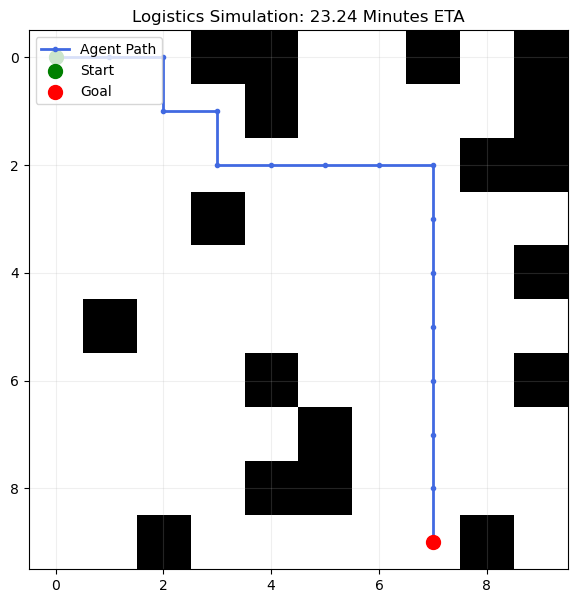

In [14]:
import heapq
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import random

#  PART 1: THE LOGISTICS ENVIRONMENT
# Defining a 10x10 grid. 0 = Clear, 1 = Obstacle
def generate_grid_world(size=10, obstacle_count=18):
    # Start with a zeroed-out array
    grid = np.zeros((size, size))
    
    # Manual loop to place obstacles so we don't accidentally overwrite the start/goal
    placed = 0
    while placed < obstacle_count:
        r, c = random.randint(0, size-1), random.randint(0, size-1)
        
        # Guarding the Start (0,0) and the likely Goal area
        if (r, c) != (0, 0) and (r, c) != (9, 9):
            if grid[r, c] == 0:  # Only place if the spot is empty
                grid[r, c] = 1
                placed += 1
    return grid

# Initializing our map and random delivery goal
my_map = generate_grid_world()
start_node = (0, 0)
delivery_goal = (random.randint(6, 9), random.randint(6, 9))

#  PART 2: PATHFINDING (A* ALGORITHM) 
def get_delivery_route(grid, start, goal):
    # 'Frontier' priority queue stores nodes to explore: (f_score, coordinates)
    frontier = []
    heapq.heappush(frontier, (0, start))
    
    came_from = {}
    g_score = {start: 0} # Cumulative cost to reach this node

    while frontier:
        # Pop the node with the lowest total estimated cost f(n) = g(n) + h(n)
        _, current = heapq.heappop(frontier)

        # Success: Backtrack to build the final path list
        if current == goal:
            final_path = []
            while current in came_from:
                final_path.append(current)
                current = came_from[current]
            final_path.append(start)
            return final_path[::-1] # Return Start-to-Goal order

        # Checking 4-way movement (Up, Down, Left, Right)
        for dr, dc in [(0, 1), (0, -1), (1, 0), (-1, 0)]:
            neighbor = (current[0] + dr, current[1] + dc)

            # Check grid boundaries and if the cell is an obstacle
            if 0 <= neighbor[0] < 10 and 0 <= neighbor[1] < 10:
                if grid[neighbor[0], neighbor[1]] == 1:
                    continue
                
                # Standard step cost is 1
                tentative_g = g_score[current] + 1 
                
                if neighbor not in g_score or tentative_g < g_score[neighbor]:
                    came_from[neighbor] = current
                    g_score[neighbor] = tentative_g
                    
                    # h(n): Manhattan Distance (admissible for grid-based movement)
                    h_n = abs(neighbor[0] - goal[0]) + abs(neighbor[1] - goal[1])
                    f_n = tentative_g + h_n
                    heapq.heappush(frontier, (f_n, neighbor))
                    
    return None # Returns None if the agent is completely blocked

#  PART 3: PREDICTIVE ETA ESTIMATOR 
# Mock training data: [Path Length, Traffic Density 0-1] -> [Minutes]
# I used specific values here to represent a typical urban delivery scenario
X_train = np.array([[10, 0.2], [22, 0.5], [35, 0.85], [14, 0.35], [20, 0.6], [8, 0.15]])
y_train = np.array([13.2, 28.5, 48.0, 19.5, 27.2, 11.0])

# Fitting the Linear Regression model
eta_model = LinearRegression()
eta_model.fit(X_train, y_train)

# PART 4: RUN SIMULATION 
route_found = get_delivery_route(my_map, start_node, delivery_goal)

if route_found:
    # Current environmental state (Traffic is a random variable here)
    live_traffic = 0.48 
    steps = len(route_found)
    
    # Predict the delivery time using our ML 'Estimator'
    predicted_eta = eta_model.predict([[steps, live_traffic]])[0]
    
    print(f"Path sequence found with {steps} nodes.")
    print(f"Predicted ETA: {predicted_eta:.2f} minutes.")

    # Visualization: Plotting the results for the report
    plt.figure(figsize=(7, 7))
    plt.imshow(my_map, cmap='binary') # 'binary' gives a clean black/white grid look
    
    # Unpack the route for plotting
    rows, cols = zip(*route_found)
    plt.plot(cols, rows, marker='o', markersize=3, color='royalblue', linewidth=2, label='Agent Path')
    
    # Plot Start/Goal markers
    plt.scatter(start_node[1], start_node[0], color='green', s=100, label='Start', zorder=5)
    plt.scatter(delivery_goal[1], delivery_goal[0], color='red', s=100, label='Goal', zorder=5)
    
    plt.title(f"Logistics Simulation: {predicted_eta:.2f} Minutes ETA")
    plt.legend(loc='upper left')
    plt.grid(alpha=0.2) # Adding a subtle grid for better spatial context
    plt.show()
else:
    print("Agent failed to find a rational path. Check for grid blockage.")
    # Show the blocked map to verify the 'No-Path' state
    plt.imshow(my_map, cmap='binary')
    plt.scatter(delivery_goal[1], delivery_goal[0], color='red', label='Goal (Unreachable)')
    plt.title("Pathfinding Failed: Destination Blocked")
    plt.show()